In [15]:
import os
import glob
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ==========================================
# ⚙️ НАСТРОЙКИ (ИЗМЕНИТЕ ПУТЬ ЗДЕСЬ)
# ==========================================
RESULTS_DIR = 'CNN_results'  # Укажите папку, где лежат ваши csv файлы
# Если файлы в той же папке, оставьте '.'

# Настройка стиля
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.1)

search_pattern = os.path.join(RESULTS_DIR, 'cnn*.csv')
files = glob.glob(search_pattern)

print(f"🔍 Найдено файлов по шаблону 'cnn*.csv': {len(files)}")

if len(files) == 0:
    print("⚠️ Файлы не найдены! Проверьте путь в переменной RESULTS_DIR.")
else:
    all_dfs = []
    
    for file_path in files:
        try:
            # Читаем CSV.
            # sep=';' и decimal=',' часто используются в Excel-экспортах, 
            # если у вас обычные точки и запятые, pandas поймет сам, но лучше указать явно при ошибках.
            df = pd.read_csv(file_path, sep=';', decimal=',') 
            
            # Добавляем имя файла как источник (полезно для отладки)
            df['Source_File'] = os.path.basename(file_path)
            
            # Убираем пробелы в названиях колонок (на случай опечаток в файлах)
            df.columns = df.columns.str.strip()
            
            all_dfs.append(df)
            print(f"   ✅ Загружен: {os.path.basename(file_path)} ({len(df)} строк)")
            
        except Exception as e:
            print(f"   ❌ Ошибка чтения {os.path.basename(file_path)}: {e}")

    # ==========================================
    # 📊 ОБЪЕДИНЕНИЕ В ОДНУ ТАБЛИЦУ
    # ==========================================
    if all_dfs:
        summary_df = pd.concat(all_dfs, ignore_index=True)
        
        # Приводим типы данных к числовым (на случай если они загрузились как текст)
        numeric_cols = ['Trades', 'Win Rate %', 'Total Return %', 'Avg Trade %', 
                        'Profit Factor', 'Avg RR', 'Sharpe', 'MDE %', 'Avg Hold Days']
        
        for col in numeric_cols:
            if col in summary_df.columns:
                summary_df[col] = pd.to_numeric(summary_df[col], errors='coerce')

        print(f"\n🚀 Итого собрано строк: {len(summary_df)}")
        print(f"📋 Колонки: {list(summary_df.columns)}")
        
        # Показываем результат
        display(summary_df.head())
    else:
        print("Не удалось загрузить данные.")

🔍 Найдено файлов по шаблону 'cnn*.csv': 6
   ✅ Загружен: cnn_res_alpha_1.5_thres_075.csv (6 строк)
   ✅ Загружен: cnn_res_alpha_2_thres_075.csv (6 строк)
   ✅ Загружен: cnn_res_alpha_2_thres_065.csv (6 строк)
   ✅ Загружен: cnn_res_alpha_2_thres_08.csv (6 строк)
   ✅ Загружен: cnn_res_alpha_1.5_thres_08.csv (6 строк)
   ✅ Загружен: cnn_res_alpha_2_thres_085.csv (6 строк)

🚀 Итого собрано строк: 36
📋 Колонки: ['Ticker', 'Trades', 'Win Rate %', 'Total Return %', 'Avg Trade %', 'Profit Factor', 'Avg RR', 'Sharpe', 'MDE %', 'Stat Sig', 'Avg Hold Days', 'Source_File']


,Ticker,Trades,Win Rate %,Total Return %,Avg Trade %,Profit Factor,Avg RR,Sharpe,MDE %,Stat Sig,Avg Hold Days,Source_File
0,GLDRUB_TOM,109,57.80,62.70,0.58,3.38,2.42,1.90,0.85,Нет,5.9,cnn_res_alpha_1.5_thres_075.csv
1,YDEX,111,54.05,47.77,0.43,1.57,1.25,1.33,0.91,Нет,5.8,cnn_res_alpha_1.5_thres_075.csv
2,VTBR,115,53.04,5.83,0.05,1.07,0.93,0.14,1.03,Нет,2.6,cnn_res_alpha_1.5_thres_075.csv
3,LKOH,149,51.01,-11.48,-0.08,0.88,0.83,-0.33,0.66,Нет,4.1,cnn_res_alpha_1.5_thres_075.csv
4,TATN,181,42.54,-21.24,-0.12,0.84,1.14,-0.51,0.65,Нет,3.3,cnn_res_alpha_1.5_thres_075.csv


In [16]:
def create_plots_directory():
    """Создаёт директорию для графиков"""
    plots_dir = Path('plots')
    plots_dir.mkdir(exist_ok=True)
    return plots_dir

In [17]:
def plot_metrics_comparison(summary_df, plots_dir):
    """
    Горизонтальные бар-чарты для ключевых метрик
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Сравнение эффективности стратегии по тикерам', fontsize=16, fontweight='bold')
    
    # 1. Total Return
    colors = ['green' if x > 0 else 'red' for x in summary_df['Total Return %']]
    axes[0, 0].barh(summary_df['Ticker'], summary_df['Total Return %'], 
                    color=colors, alpha=0.7, edgecolor='black')
    axes[0, 0].set_xlabel('Доходность (%)', fontsize=11)
    axes[0, 0].set_title('Общая доходность', fontsize=12, fontweight='bold')
    axes[0, 0].axvline(0, color='black', linewidth=0.8)
    axes[0, 0].grid(True, alpha=0.3, axis='x')
    
    # 2. Sharpe Ratio
    colors = ['green' if x > 1 else 'orange' if x > 0 else 'red' for x in summary_df['Sharpe']]
    axes[0, 1].barh(summary_df['Ticker'], summary_df['Sharpe'],
                    color=colors, alpha=0.7, edgecolor='black')
    axes[0, 1].set_xlabel('Sharpe Ratio', fontsize=11)
    axes[0, 1].set_title('Risk-Adjusted Return (Sharpe)', fontsize=12, fontweight='bold')
    axes[0, 1].axvline(0, color='black', linewidth=0.8)
    axes[0, 1].axvline(1, color='green', linestyle='--', alpha=0.5, label='Хорошо (>1)')
    axes[0, 1].legend(loc='lower right')
    axes[0, 1].grid(True, alpha=0.3, axis='x')
    
    # 3. Profit Factor
    colors = ['green' if x > 1.5 else 'orange' if x > 1 else 'red' for x in summary_df['Profit Factor']]
    axes[0, 2].barh(summary_df['Ticker'], summary_df['Profit Factor'],
                    color=colors, alpha=0.7, edgecolor='black')
    axes[0, 2].set_xlabel('Profit Factor', fontsize=11)
    axes[0, 2].set_title('Profit Factor (прибыль/убыток)', fontsize=12, fontweight='bold')
    axes[0, 2].axvline(1, color='black', linewidth=0.8, label='Безубыток')
    axes[0, 2].axvline(1.5, color='green', linestyle='--', alpha=0.5, label='Хорошо (>1.5)')
    axes[0, 2].legend(loc='lower right')
    axes[0, 2].grid(True, alpha=0.3, axis='x')
    
    # 4. Win Rate
    colors = ['green' if x > 50 else 'orange' if x > 45 else 'red' for x in summary_df['Win Rate %']]
    axes[1, 0].barh(summary_df['Ticker'], summary_df['Win Rate %'],
                    color=colors, alpha=0.7, edgecolor='black')
    axes[1, 0].set_xlabel('Win Rate (%)', fontsize=11)
    axes[1, 0].set_title('Процент прибыльных сделок', fontsize=12, fontweight='bold')
    axes[1, 0].axvline(50, color='black', linestyle='--', linewidth=0.8)
    axes[1, 0].grid(True, alpha=0.3, axis='x')
    
    # 5. Number of Trades
    axes[1, 1].barh(summary_df['Ticker'], summary_df['Trades'],
                    color='steelblue', alpha=0.7, edgecolor='black')
    axes[1, 1].set_xlabel('Количество', fontsize=11)
    axes[1, 1].set_title('Всего сделок', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3, axis='x')
    
    # 6. Average Holding Period
    axes[1, 2].barh(summary_df['Ticker'], summary_df['Avg Hold Days'],
                    color='purple', alpha=0.7, edgecolor='black')
    axes[1, 2].set_xlabel('Дней', fontsize=11)
    axes[1, 2].set_title('Средний holding period', fontsize=12, fontweight='bold')
    axes[1, 2].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig(plots_dir / 'metrics_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Сохранено: metrics_comparison.png")

In [18]:
def plot_risk_return_scatter(summary_df, plots_dir):
    """
    Диаграмма рассеяния: Sharpe vs Total Return
    """
    plt.figure(figsize=(12, 8))
    
    # Цвет по прибыльности
    colors = ['green' if x > 0 else 'red' for x in summary_df['Total Return %']]
    sizes = [50 + x * 5 for x in summary_df['Trades']]  # Размер по количеству сделок
    
    for idx, row in summary_df.iterrows():
        plt.scatter(row['Sharpe'], row['Total Return %'], 
                   s=sizes[idx], alpha=0.6, edgecolors='black', linewidth=1.5,
                   c=colors[idx])
        plt.annotate(row['Ticker'], (row['Sharpe'], row['Total Return %']), 
                    fontsize=10, ha='center', va='bottom', fontweight='bold')
    
    plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    plt.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    plt.axvline(1, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Sharpe > 1 (хорошо)')
    plt.axhline(summary_df['Total Return %'].mean(), color='blue', linestyle=':', 
               linewidth=1.5, alpha=0.7, label=f'Средняя доходность: {summary_df["Total Return %"].mean():.1f}%')
    
    plt.xlabel('Sharpe Ratio', fontsize=13, fontweight='bold')
    plt.ylabel('Total Return (%)', fontsize=13, fontweight='bold')
    plt.title('Risk-Adjusted Performance: Sharpe vs Return\n(размер точки = количество сделок)', 
             fontsize=14, fontweight='bold', pad=20)
    plt.legend(loc='best', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(plots_dir / 'risk_return_scatter.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Сохранено: risk_return_scatter.png")

In [19]:
def plot_correlation_heatmap(summary_df, plots_dir):
    """
    Тепловая карта корреляций между метриками
    """
    plt.figure(figsize=(12, 10))
    
    # Выбираем числовые колонки
    numeric_cols = ['Total Return %', 'Sharpe', 'Profit Factor', 'Win Rate %', 
                   'Avg Trade %', 'Trades', 'Avg Hold Days', 'Avg RR']
    corr_matrix = summary_df[numeric_cols].corr()
    
    # Маска для верхней треугольной матрицы
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0,
                fmt='.2f', square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8}, mask=mask,
                annot_kws={"size": 10})
    
    plt.title('Корреляция между метриками стратегии', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(plots_dir / 'correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Сохранено: correlation_heatmap.png")

In [20]:
def plot_boxplot_by_ticker(summary_df, plots_dir):
    """
    Box plot распределения метрик по тикерам
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Sharpe
    colors = ['green' if x > 1 else 'orange' if x > 0 else 'red' for x in summary_df['Sharpe']]
    axes[0, 0].bar(summary_df['Ticker'], summary_df['Sharpe'], color=colors, alpha=0.7, edgecolor='black')
    axes[0, 0].set_ylabel('Sharpe Ratio', fontsize=11)
    axes[0, 0].set_title('Sharpe Ratio по тикерам', fontsize=12, fontweight='bold')
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[0, 0].axhline(1, color='green', linestyle='--', linewidth=1, alpha=0.5)
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # Total Return
    colors = ['green' if x > 0 else 'red' for x in summary_df['Total Return %']]
    axes[0, 1].bar(summary_df['Ticker'], summary_df['Total Return %'], color=colors, alpha=0.7, edgecolor='black')
    axes[0, 1].set_ylabel('Total Return (%)', fontsize=11)
    axes[0, 1].set_title('Общая доходность (%) по тикерам', fontsize=12, fontweight='bold')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Win Rate
    colors = ['green' if x > 50 else 'orange' if x > 45 else 'red' for x in summary_df['Win Rate %']]
    axes[1, 0].bar(summary_df['Ticker'], summary_df['Win Rate %'], color=colors, alpha=0.7, edgecolor='black')
    axes[1, 0].set_ylabel('Win Rate (%)', fontsize=11)
    axes[1, 0].set_title('Win Rate (%) по тикерам', fontsize=12, fontweight='bold')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].axhline(50, color='gray', linestyle='--', linewidth=0.8)
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Profit Factor
    colors = ['green' if x > 1.5 else 'orange' if x > 1 else 'red' for x in summary_df['Profit Factor']]
    axes[1, 1].bar(summary_df['Ticker'], summary_df['Profit Factor'], color=colors, alpha=0.7, edgecolor='black')
    axes[1, 1].set_ylabel('Profit Factor', fontsize=11)
    axes[1, 1].set_title('Profit Factor по тикерам', fontsize=12, fontweight='bold')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].axhline(1, color='gray', linestyle='--', linewidth=0.8)
    axes[1, 1].axhline(1.5, color='green', linestyle='--', linewidth=1, alpha=0.5)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(plots_dir / 'boxplot_by_ticker.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Сохранено: boxplot_by_ticker.png")

In [21]:
def plot_stat_sig_analysis(summary_df, plots_dir):
    """
    Анализ статистической значимости
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. MDE vs Avg Trade
    colors = ['green' if abs(row['Avg Trade %']) > row['MDE %'] else 'red' for _, row in summary_df.iterrows()]
    significant = summary_df['Stat Sig'].apply(lambda x: 'ДА' in str(x))
    
    axes[0].scatter(summary_df['Avg Trade %'], summary_df['MDE %'], 
                   c=colors, s=100, alpha=0.7, edgecolors='black', linewidth=1.5)
    
    for idx, row in summary_df.iterrows():
        axes[0].annotate(row['Ticker'], (row['Avg Trade %'], row['MDE %']), 
                        fontsize=9, ha='center', va='bottom')
    
    # Линия y=x (порог значимости)
    x_min = min(summary_df['Avg Trade %'].min(), summary_df['MDE %'].min())
    x_max = max(summary_df['Avg Trade %'].max(), summary_df['MDE %'].max())
    axes[0].plot([x_min, x_max], [x_min, x_max], 'r--', linewidth=2, label='Порог значимости')
    
    axes[0].set_xlabel('Avg Trade %', fontsize=12)
    axes[0].set_ylabel('MDE %', fontsize=12)
    axes[0].set_title('Статистическая значимость: Avg Trade vs MDE', fontsize=13, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. Pie chart значимых/незначимых
    sig_counts = summary_df['Stat Sig'].value_counts()
    colors_pie = ['green' if 'ДА' in str(x) else 'red' for x in sig_counts.index]
    axes[1].pie(sig_counts.values, labels=sig_counts.index, autopct='%1.1f%%',
               colors=colors_pie, startangle=90, explode=[0.05] * len(sig_counts))
    axes[1].set_title('Распределение по статистической значимости', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(plots_dir / 'stat_sig_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Сохранено: stat_sig_analysis.png")

In [22]:
def plot_performance_ranking(summary_df, plots_dir):
    """
    Комплексный рейтинг тикеров по 4 ключевым метрикам:
    Total Return %, Sharpe, Profit Factor, Win Rate %
    """
    df_norm = summary_df.copy()
    
    # Метрики для рейтинга (чем выше, тем лучше)
    metrics = ['Total Return %', 'Sharpe', 'Profit Factor', 'Win Rate %']
    
    # Безопасная мин-макс нормализация
    for col in metrics:
        min_val = df_norm[col].min()
        max_val = df_norm[col].max()
        if max_val > min_val:
            df_norm[f'{col}_norm'] = (df_norm[col] - min_val) / (max_val - min_val)
        else:
            df_norm[f'{col}_norm'] = 0.5  # защита от деления на 0
            
    # Комплексный скор = среднее нормализованных метрик
    norm_cols = [f'{col}_norm' for col in metrics]
    df_norm['Composite_Score'] = df_norm[norm_cols].mean(axis=1)
    
    # Сортировка для горизонтального графика
    df_norm = df_norm.sort_values('Composite_Score', ascending=True).reset_index(drop=True)
    
    plt.figure(figsize=(12, 7))
    mean_score = df_norm['Composite_Score'].mean()
    colors = ['green' if x >= mean_score else 'orange' for x in df_norm['Composite_Score']]
    
    bars = plt.barh(df_norm['Ticker'], df_norm['Composite_Score'], 
                    color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Подписи значений справа от баров
    for bar, score in zip(bars, df_norm['Composite_Score']):
        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{score:.3f}', va='center', fontsize=10, fontweight='bold')
        
    plt.axvline(mean_score, color='red', linestyle='--', linewidth=1.5, 
                label=f'Средний: {mean_score:.3f}')
    plt.xlabel('Комплексный скор (нормализованный)', fontsize=12)
    plt.title('Рейтинг тикеров по комплексной эффективности\n(Sharpe + Return + PF + Win Rate)', 
              fontsize=14, fontweight='bold', pad=15)
    plt.xlim(0, max(df_norm['Composite_Score']) * 1.15)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    
    plt.savefig(plots_dir / 'performance_ranking.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Сохранено: performance_ranking.png")

In [23]:
def plot_trades_vs_performance(summary_df, plots_dir):
    """
    Scatter plot: количество сделок vs производительность
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Trades vs Sharpe
    colors = ['green' if x > 0 else 'red' for x in summary_df['Sharpe']]
    axes[0].scatter(summary_df['Trades'], summary_df['Sharpe'], 
                   c=colors, s=100, alpha=0.7, edgecolors='black', linewidth=1.5)
    
    for idx, row in summary_df.iterrows():
        axes[0].annotate(row['Ticker'], (row['Trades'], row['Sharpe']), 
                        fontsize=10, ha='center', va='bottom')
    
    axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[0].axhline(1, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Sharpe > 1')
    axes[0].set_xlabel('Количество сделок', fontsize=12)
    axes[0].set_ylabel('Sharpe Ratio', fontsize=12)
    axes[0].set_title('Влияние количества сделок на Sharpe Ratio', fontsize=13, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. Trades vs Total Return
    colors = ['green' if x > 0 else 'red' for x in summary_df['Total Return %']]
    axes[1].scatter(summary_df['Trades'], summary_df['Total Return %'], 
                   c=colors, s=100, alpha=0.7, edgecolors='black', linewidth=1.5)
    
    for idx, row in summary_df.iterrows():
        axes[1].annotate(row['Ticker'], (row['Trades'], row['Total Return %']), 
                        fontsize=10, ha='center', va='bottom')
    
    axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[1].axhline(summary_df['Total Return %'].mean(), color='blue', linestyle=':', 
                   linewidth=1.5, alpha=0.7, label=f'Средняя: {summary_df["Total Return %"].mean():.1f}%')
    axes[1].set_xlabel('Количество сделок', fontsize=12)
    axes[1].set_ylabel('Total Return (%)', fontsize=12)
    axes[1].set_title('Влияние количества сделок на доходность', fontsize=13, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(plots_dir / 'trades_vs_performance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Сохранено: trades_vs_performance.png")

In [24]:
def run_all_visualizations(summary_df):
    """
    Запускает все визуализации
    """
    print("="*70)
    print("🚀 ЗАПУСК ВИЗУАЛИЗАЦИЙ")
    print("="*70)
    
    # Создаём директорию
    plots_dir = create_plots_directory()
    print(f"📁 Директория для графиков: {plots_dir.absolute()}")
    print()
    
    # Запускаем все визуализации
    plot_metrics_comparison(summary_df, plots_dir)
    plot_risk_return_scatter(summary_df, plots_dir)
    plot_correlation_heatmap(summary_df, plots_dir)
    plot_boxplot_by_ticker(summary_df, plots_dir)
    plot_stat_sig_analysis(summary_df, plots_dir)
    plot_performance_ranking(summary_df, plots_dir)
    plot_trades_vs_performance(summary_df, plots_dir)
    
    print()
    print("="*70)
    print("✅ ВСЕ ВИЗУАЛИЗАЦИИ СОХРАНЕНЫ В ПАПКУ 'plots/'")
    print("="*70)
    print("\nСписок созданных файлов:")
    for f in sorted(plots_dir.glob('*.png')):
        print(f"  • {f.name}")
    print()

🚀 ЗАПУСК ВИЗУАЛИЗАЦИЙ
📁 Директория для графиков: /Users/alexsmirnov/Master_Degree/FQW/fqw_master_degree/plots



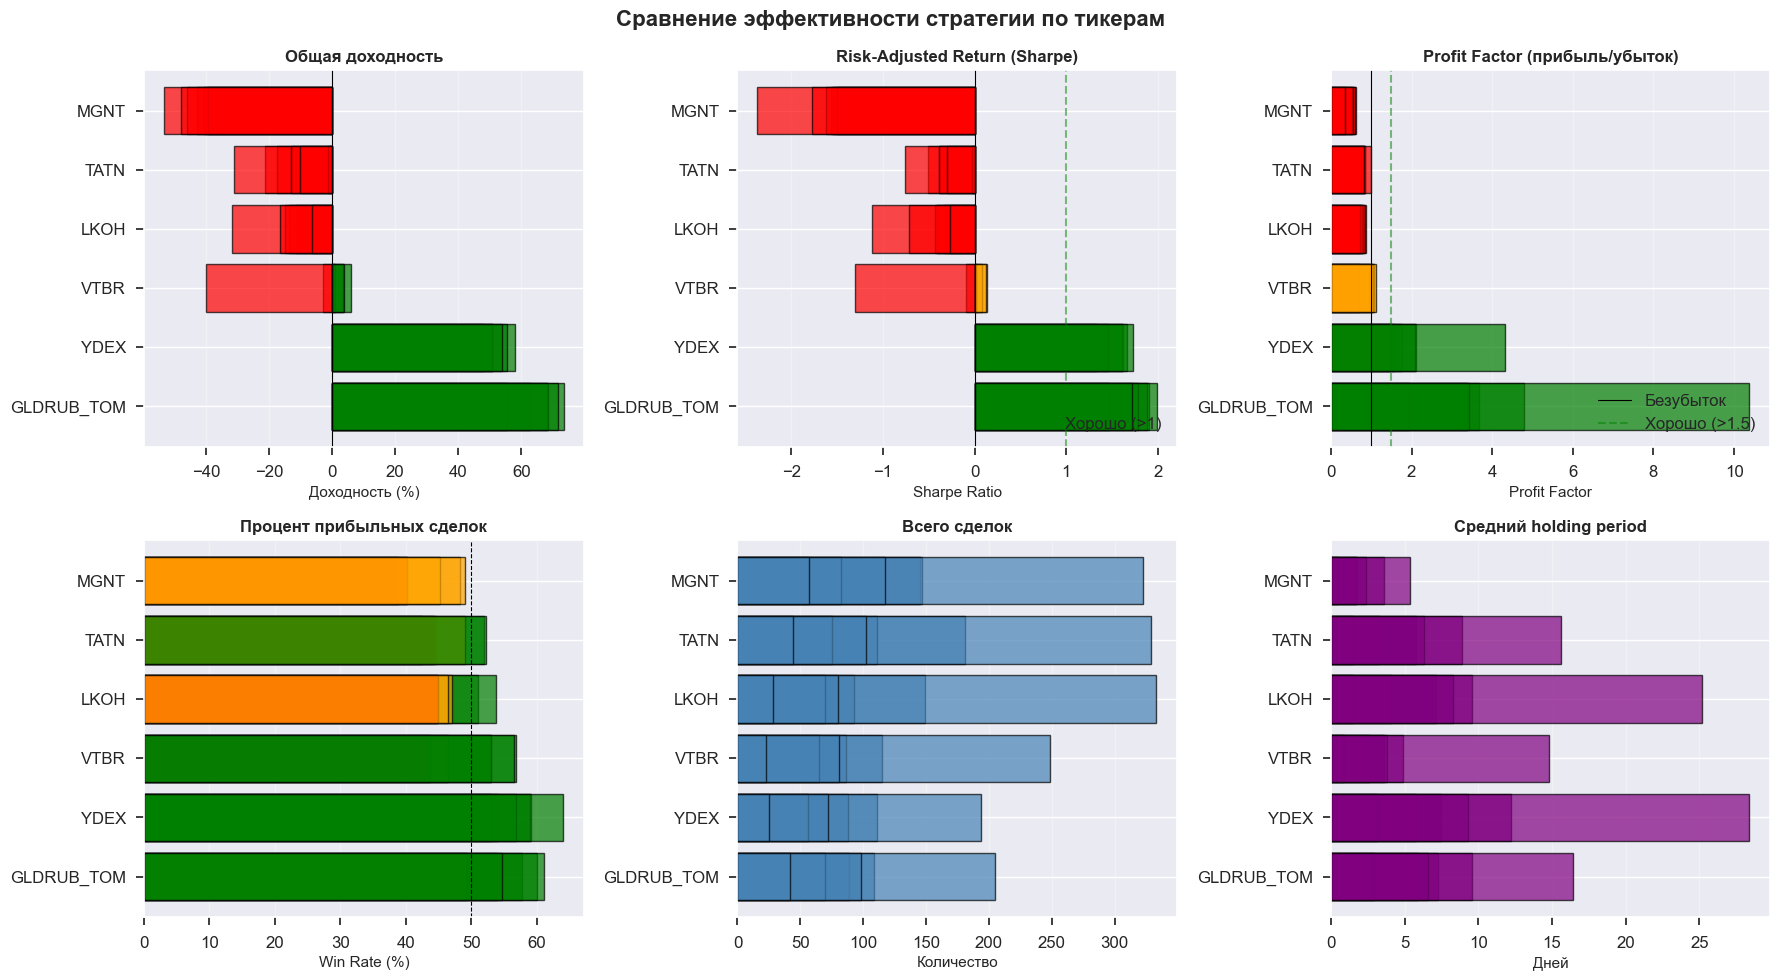

✅ Сохранено: metrics_comparison.png


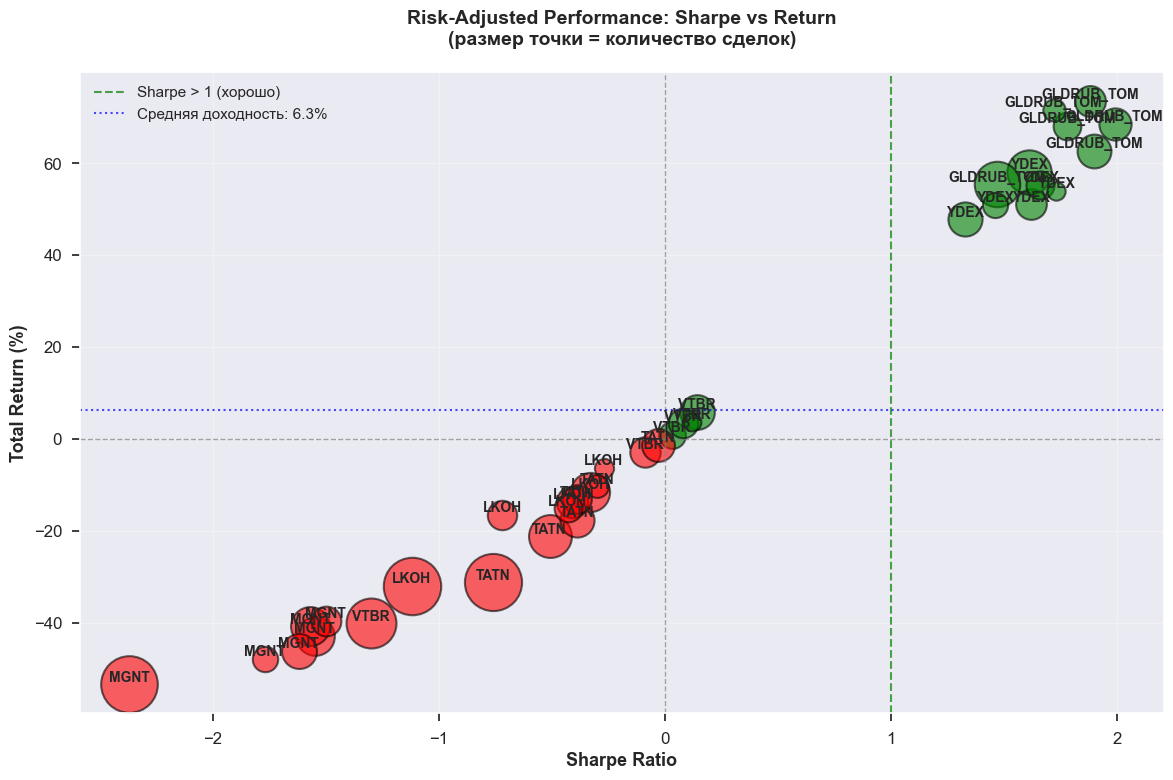

✅ Сохранено: risk_return_scatter.png


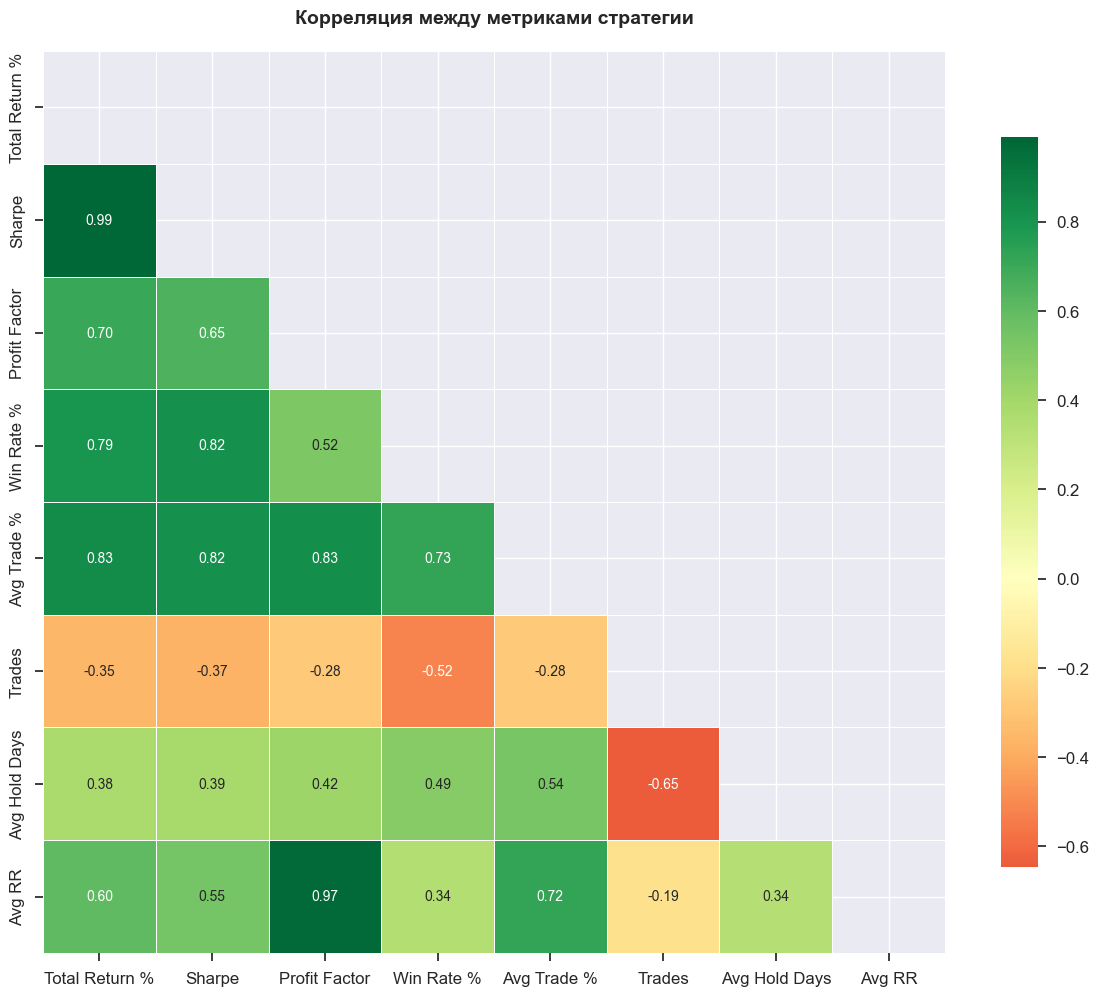

✅ Сохранено: correlation_heatmap.png


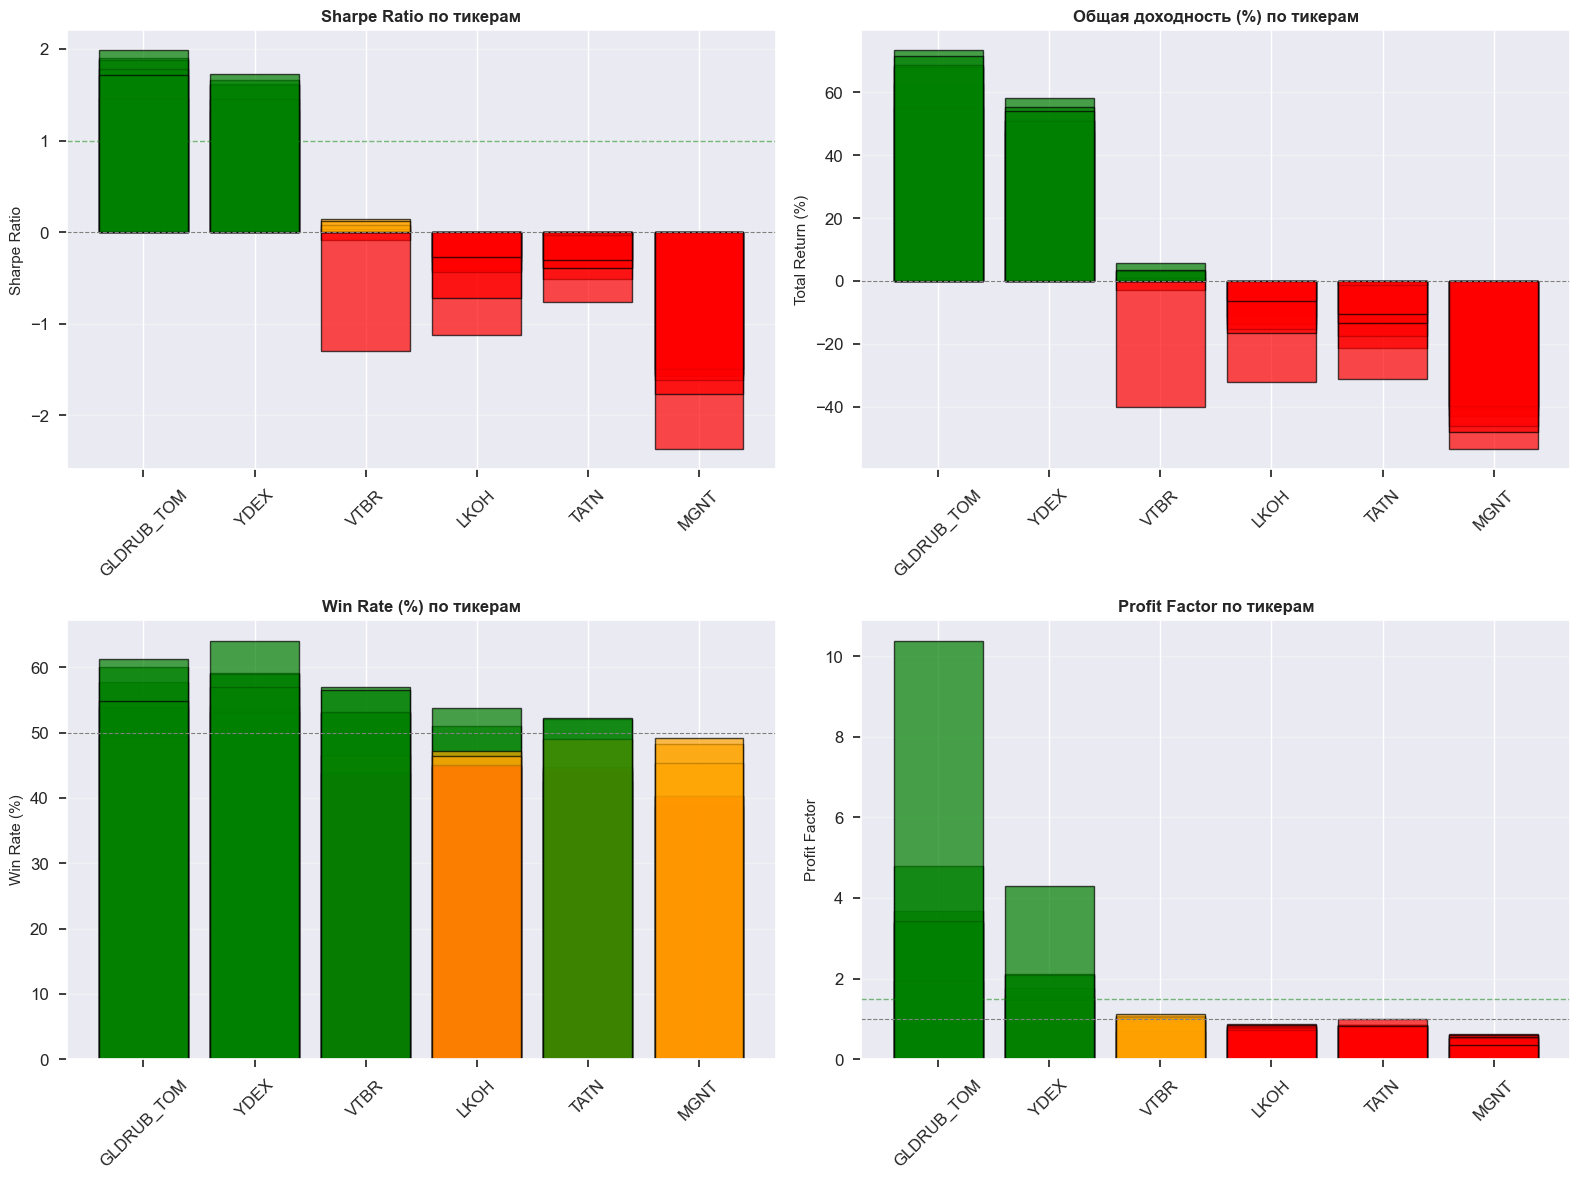

✅ Сохранено: boxplot_by_ticker.png


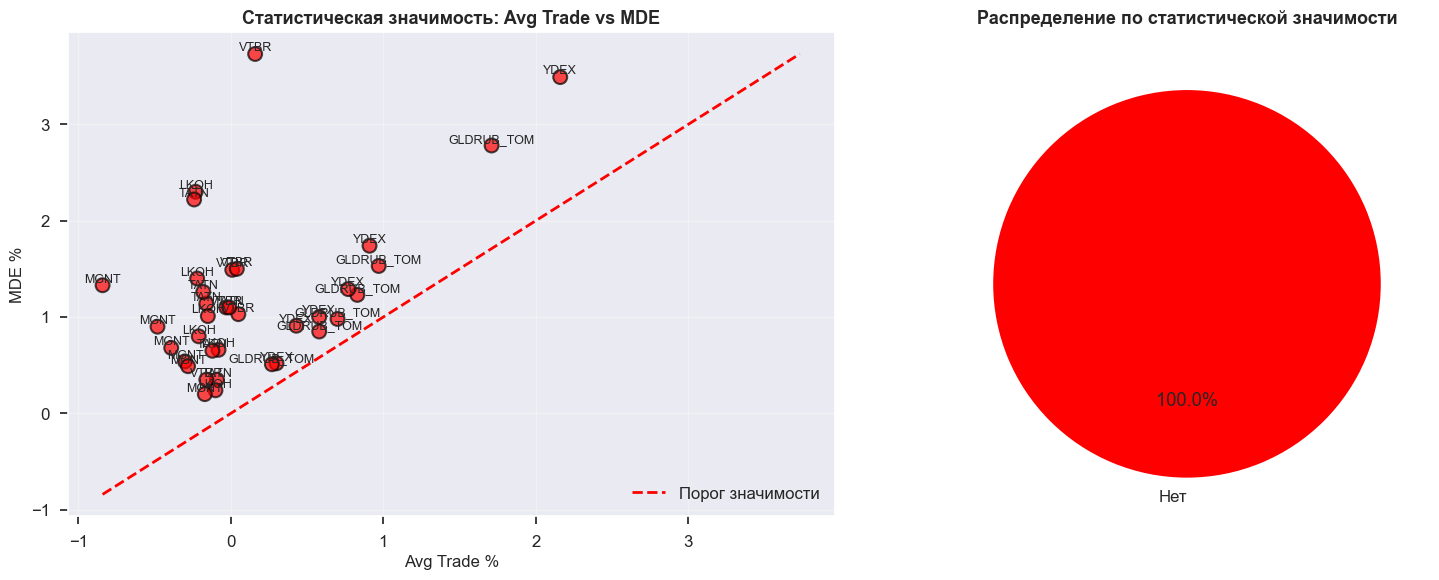

✅ Сохранено: stat_sig_analysis.png


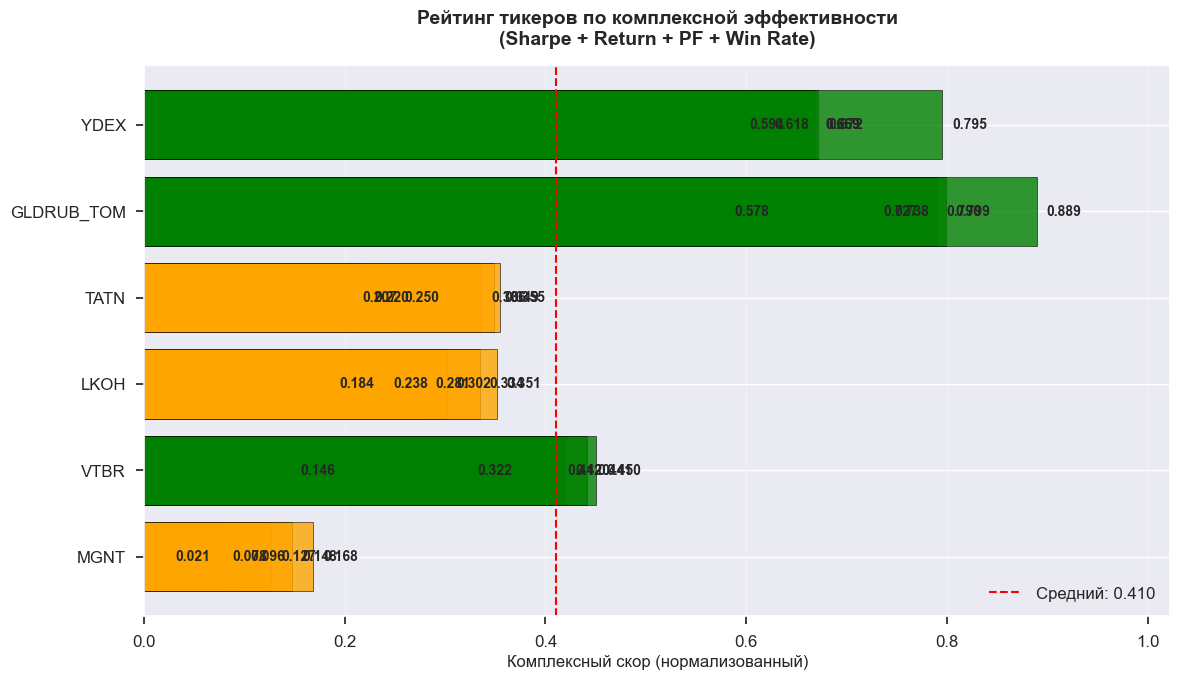

✅ Сохранено: performance_ranking.png


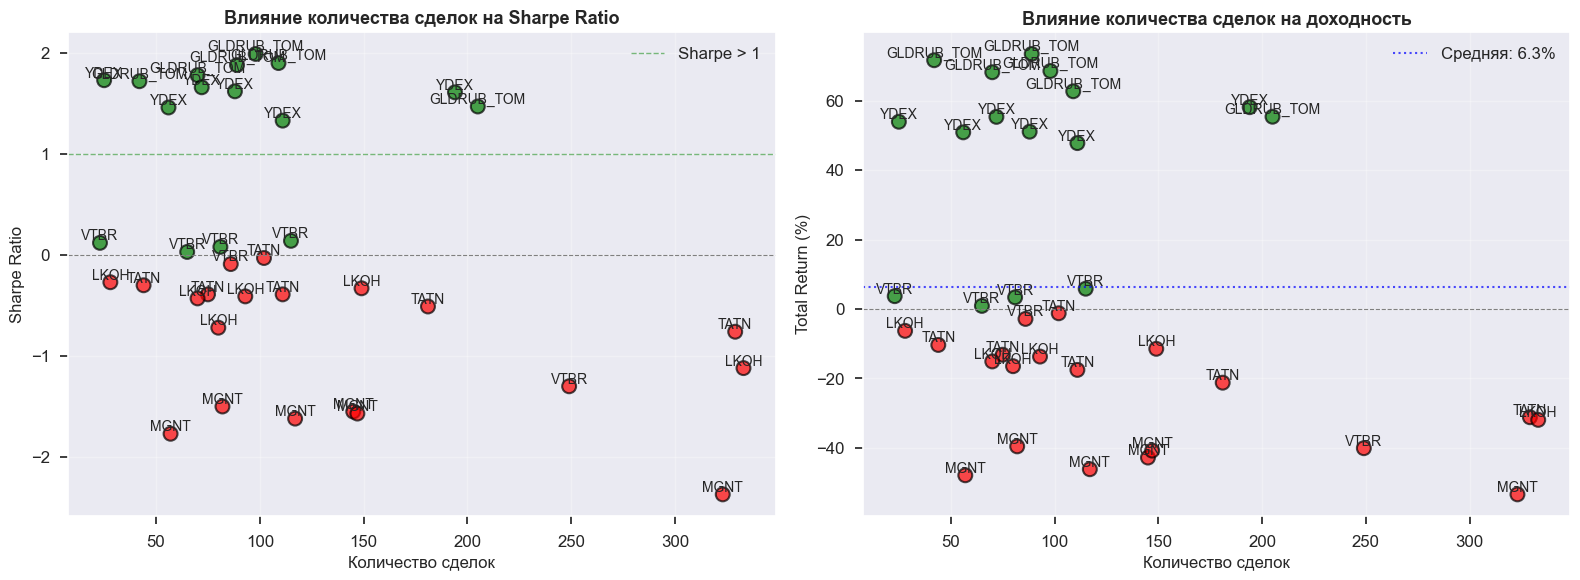

✅ Сохранено: trades_vs_performance.png

✅ ВСЕ ВИЗУАЛИЗАЦИИ СОХРАНЕНЫ В ПАПКУ 'plots/'

Список созданных файлов:
  • boxplot_by_ticker.png
  • correlation_heatmap.png
  • metrics_comparison.png
  • performance_ranking.png
  • risk_return_scatter.png
  • stat_sig_analysis.png
  • trades_vs_performance.png



In [25]:
# Пример использования:
run_all_visualizations(summary_df)